In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score,
)
from sklearn.calibration import CalibrationDisplay
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')
print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# Cell 2: Setup and Data Loading

import os
import pandas as pd
from pathlib import Path

# Setup paths
SCRIPT_DIR = Path.cwd() 
PROJECT_ROOT = SCRIPT_DIR.parent.parent
CLEANED_DIR = PROJECT_ROOT / 'data' / 'cleaned'

# Load our augmented dataset
file_path = CLEANED_DIR / 'smart_travel_dataset_augmented.csv'
df = pd.read_csv(file_path)

print(f'Working shape: {df.shape}')
print(f'Columns ({len(df.columns)}): {list(df.columns)}')
display(df.head())

Working shape: (864, 11)
Columns (11): ['city', 'country', 'lat', 'lng', 'Primary_Activity', 'Trip_Pace', 'Cost of Living Index', 'Tourist_Cost_Score', 'Dining_Out_Premium', 'City_Scale', 'Travel_Style']


,city,country,lat,lng,Primary_Activity,Trip_Pace,Cost of Living Index,Tourist_Cost_Score,Dining_Out_Premium,City_Scale,Travel_Style
0,Tokyo,Japan,35.687,139.7495,Climbing Mount Fuji from Tokyo base camps,Fast,85.61,68.935,0.550453,Megacity,Adventure
1,Tokyo,Japan,35.687,139.7495,Tea ceremony experience in traditional Asakusa...,Relaxed,85.61,68.935,0.550453,Megacity,Culture
2,Tokyo,Japan,35.687,139.7495,Shopping at Shibuya Crossing and luxury boutiques,Fast,85.61,68.935,0.550453,Megacity,Luxury
3,Tokyo,Japan,35.687,139.7495,Exploring budget ramen shops and izakayas in S...,Moderate,85.61,68.935,0.550453,Megacity,Budget
4,Tokyo,Japan,35.687,139.7495,Teamlab Borderless digital art museum immersion,Moderate,85.61,68.935,0.550453,Megacity,Culture


In [3]:
# Cell 3: Target Setup & Splitting

# Separate features (X) from target (y)
X = df.drop(columns=['Travel_Style'])
y = df['Travel_Style']

# Look at the overall class distribution before splitting
print('Overall travel style distribution:')
print(y.value_counts(normalize=True).round(3))
print()

from sklearn.model_selection import train_test_split

# NOTE: The instructor used train_test_split. However, because we augmented the data
# (turning 1 city into 8 rows), we MUST use GroupShuffleSplit.
# If we don't, Tokyo Row 1 might go to Train, and Tokyo Row 2 to Test, causing a massive data leak.

from sklearn.model_selection import GroupShuffleSplit

# Step 1: Split out the 20% Test set, keeping cities grouped
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_val_idx, test_idx = next(gss1.split(X, y, groups=X['city']))

X_temp = X.iloc[train_val_idx]
y_temp = y.iloc[train_val_idx]
X_test = X.iloc[test_idx]
y_test = y.iloc[test_idx]

# Step 2: Split the remaining 80% into Train (60%) and Validation (20%)
# 20% is exactly 25% of the remaining 80%
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, val_idx = next(gss2.split(X_temp, y_temp, groups=X_temp['city']))

X_train = X_temp.iloc[train_idx]
y_train = y_temp.iloc[train_idx]
X_val = X_temp.iloc[val_idx]
y_val = y_temp.iloc[val_idx]

print(f'  Train : {X_train.shape}')
print(f'  Val   : {X_val.shape}')
print(f'  Test  : {X_test.shape}')

# Let's verify our groups didn't leak!
train_cities = set(X_train['city'])
val_cities = set(X_val['city'])
test_cities = set(X_test['city'])

leak_val = train_cities.intersection(val_cities)
leak_test = train_cities.intersection(test_cities)

print(f"\\nData Leak Check - Train/Val intersection: {len(leak_val)} cities")
print(f"Data Leak Check - Train/Test intersection: {len(leak_test)} cities")

Overall travel style distribution:
Travel_Style
Culture       0.299
Adventure     0.183
Budget        0.153
Luxury        0.142
Family        0.124
Relaxation    0.100
Name: proportion, dtype: float64

  Train : (520, 10)
  Val   : (176, 10)
  Test  : (168, 10)
\nData Leak Check - Train/Val intersection: 0 cities
Data Leak Check - Train/Test intersection: 0 cities


In [4]:
# Cell 4: Numeric Shape and Balance Verification
import pandas as pd

print('=' * 60)
print(f"{'Split':<10} | {'Total Rows':<12} | {'Unique Cities':<15}")
print('=' * 60)
print(f"{'Train':<10} | {len(X_train):<12} | {X_train['city'].nunique():<15}")
print(f"{'Val':<10} | {len(X_val):<12} | {X_val['city'].nunique():<15}")
print(f"{'Test':<10} | {len(X_test):<12} | {X_test['city'].nunique():<15}")
print('=' * 60)

# Calculate the percentage distribution of Travel Styles in each split
dist_df = pd.DataFrame({
    'Train %': y_train.value_counts(normalize=True) * 100,
    'Val %': y_val.value_counts(normalize=True) * 100,
    'Test %': y_test.value_counts(normalize=True) * 100
}).round(1)

print("\nTravel Style Distribution Across Splits (%):")
print("(Note: Slight variations are expected because we split by City groups, not pure stratification)")
display(dist_df)

Split      | Total Rows   | Unique Cities  
Train      | 520          | 61             
Val        | 176          | 21             
Test       | 168          | 21             

Travel Style Distribution Across Splits (%):
(Note: Slight variations are expected because we split by City groups, not pure stratification)


,Train %,Val %,Test %
Travel_Style,,,
Adventure,19.0,18.2,16.1
Budget,15.4,16.5,13.7
Culture,28.3,30.7,33.9
Family,12.7,11.4,12.5
Luxury,14.4,13.1,14.9
Relaxation,10.2,10.2,8.9


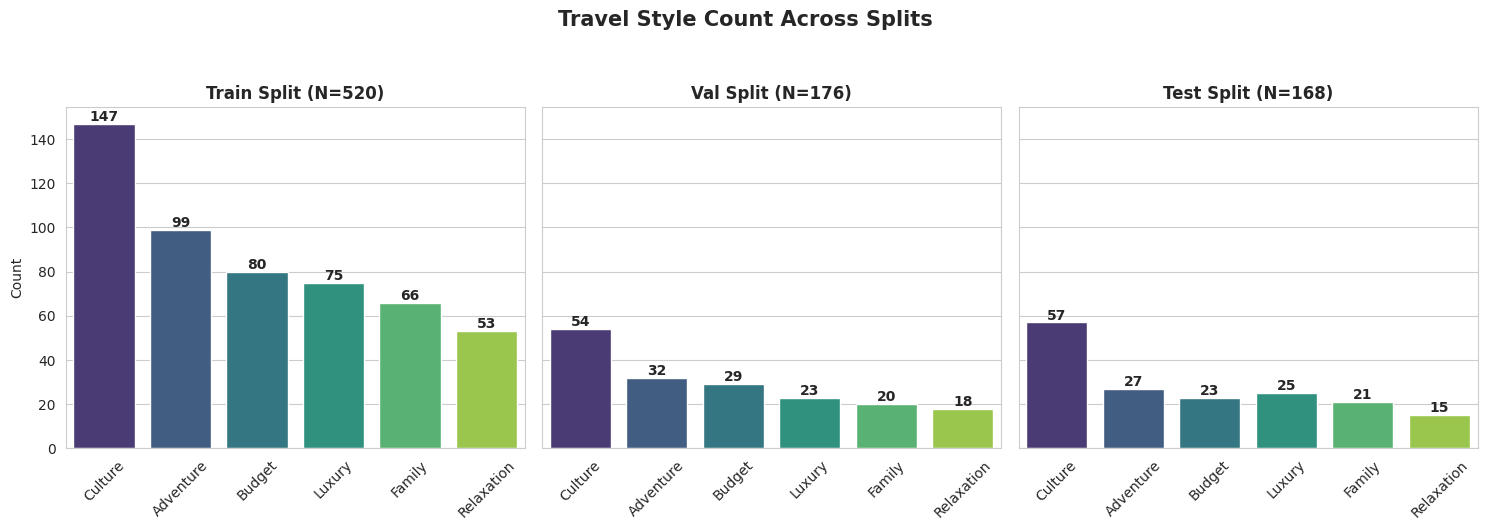

In [5]:
# Cell 5: Visual Class Distribution Across Splits
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
splits = [('Train', y_train), ('Val', y_val), ('Test', y_test)]

# Order by overall frequency so the bars align nicely across subplots
styles_order = y.value_counts().index.tolist() 

for ax, (name, y_s) in zip(axes, splits):
    sns.countplot(x=y_s, order=styles_order, palette='viridis', ax=ax)
    
    ax.set_title(f'{name} Split (N={len(y_s)})', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count' if name == 'Train' else '')
    ax.tick_params(axis='x', rotation=45)
    
    # Add count labels on top of each bar
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 5), 
                    textcoords = 'offset points',
                    fontsize=10, fontweight='bold')

plt.suptitle('Travel Style Count Across Splits', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [12]:
# Cell 6: Preprocessor Architecture & Baseline Model
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# 1. Identify feature types
numeric_features = ['lat', 'lng', 'Cost of Living Index', 'Tourist_Cost_Score', 'Dining_Out_Premium']
# We drop 'city' from the training features to prevent the model from memorizing answers!
categorical_features = ['Trip_Pace', 'City_Scale', 'country'] 
text_feature = 'Primary_Activity' # TfidfVectorizer expects a 1D array/series, not a list

print(f'Numeric features: {numeric_features}')
print(f'Categorical features: {categorical_features}')
print(f'Text feature: {text_feature}\n')

# 2. Build the branches
# Numeric branch: median impute + standard scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical branch: most-frequent impute + one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Text branch: TF-IDF to extract keywords from the activities (limits to top 300 words)
text_transformer = TfidfVectorizer(max_features=300, stop_words='english')

# 3. Combine branches into the Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
    ('text', text_transformer, text_feature)
], sparse_threshold=0) 

# 4. Build the Baseline Logistic Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',     # Handles our class imbalance!
        max_iter=1000,
        random_state=42
        # multi_class='multinomial' has been removed because modern scikit-learn handles it automatically!
    ))
])

print('Logistic Regression pipeline ready (Adapted for NLP).\n')

# --- TRAIN AND EVALUATE BASELINE ---
print('Training Baseline Model...')
lr_pipeline.fit(X_train, y_train)

# Predict on the Validation set
y_val_pred_lr = lr_pipeline.predict(X_val)

# Calculate metrics
lr_val_acc = accuracy_score(y_val, y_val_pred_lr)
lr_val_f1_macro = f1_score(y_val, y_val_pred_lr, average='macro')

print('=== Baseline: Logistic Regression ===')
print(f'  Val Accuracy   : {lr_val_acc:.4f}')
print(f'  Val Macro F1   : {lr_val_f1_macro:.4f}   <-- target to beat')
print('\nClassification Report:')
print(classification_report(y_val, y_val_pred_lr))

Numeric features: ['lat', 'lng', 'Cost of Living Index', 'Tourist_Cost_Score', 'Dining_Out_Premium']
Categorical features: ['Trip_Pace', 'City_Scale', 'country']
Text feature: Primary_Activity

Logistic Regression pipeline ready (Adapted for NLP).

Training Baseline Model...
=== Baseline: Logistic Regression ===
  Val Accuracy   : 0.8295
  Val Macro F1   : 0.8204   <-- target to beat

Classification Report:
              precision    recall  f1-score   support

   Adventure       0.90      0.84      0.87        32
      Budget       0.79      0.93      0.86        29
     Culture       0.93      0.78      0.85        54
      Family       0.79      0.75      0.77        20
      Luxury       0.90      0.78      0.84        23
  Relaxation       0.61      0.94      0.74        18

    accuracy                           0.83       176
   macro avg       0.82      0.84      0.82       176
weighted avg       0.85      0.83      0.83       176



In [8]:
# Cell 7: Define eval_classifier Helper

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def eval_classifier(pipeline, X_tr, y_tr, X_v, y_v, name):
    """
    Fit pipeline on (X_tr, y_tr) and evaluate on both train and val sets.

    Returns
    -------
    dict with keys: model, train_f1_macro, val_f1_macro, val_accuracy, val_precision, val_recall
    The pipeline is modified in-place (fitted state stored in the caller's variable).
    """
    # 1. Fit the model
    pipeline.fit(X_tr, y_tr)

    # 2. Make predictions
    y_tr_pred = pipeline.predict(X_tr)
    y_v_pred = pipeline.predict(X_v)

    # 3. Calculate multi-class metrics
    # We use average='macro' to treat all 6 travel styles equally, regardless of class imbalance
    return {
        'model': name,
        'train_f1_macro': f1_score(y_tr, y_tr_pred, average='macro'),
        'val_f1_macro': f1_score(y_v, y_v_pred, average='macro'),
        'val_accuracy': accuracy_score(y_v, y_v_pred),
        'val_precision': precision_score(y_v, y_v_pred, average='macro', zero_division=0),
        'val_recall': recall_score(y_v, y_v_pred, average='macro', zero_division=0),
    }

print('eval_classifier() defined for multi-class evaluation.')
print('  Tracking: train_f1_macro, val_f1_macro, val_accuracy, val_precision, val_recall')

eval_classifier() defined for multi-class evaluation.
  Tracking: train_f1_macro, val_f1_macro, val_accuracy, val_precision, val_recall


In [13]:
# Cell 8: RandomForestClassifier Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

# We clone the preprocessor so it gets a fresh, unfitted copy!
rf_pipeline = Pipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced', # Crucial for our rare travel styles
        random_state=42,
        n_jobs=-1                # Uses all your CPU cores to train faster
    ))
])

print('Random Forest pipeline built.')
print('  n_estimators : 100')
print('  class_weight : balanced')
print('  n_jobs       : -1')

Random Forest pipeline built.
  n_estimators : 100
  class_weight : balanced
  n_jobs       : -1


In [14]:
# Cell 9: HistGradientBoostingClassifier Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier

gbm_pipeline = Pipeline(steps=[
    ('preprocessor', clone(preprocessor)),      # fresh unfitted copy
    ('classifier', HistGradientBoostingClassifier(
        class_weight='balanced',
        random_state=42
        # We leave all other hyperparameters at sklearn defaults 
        # (learning_rate=0.1, max_iter=100) just like the instructor did!
    ))
])

print('HistGradientBoosting pipeline built (sklearn defaults + class_weight=balanced).')
print('  learning_rate     : 0.1     (default)')
print('  max_iter          : 100     (default)')
print('  class_weight      : balanced')
print('  random_state      : 42')

HistGradientBoosting pipeline built (sklearn defaults + class_weight=balanced).
  learning_rate     : 0.1     (default)
  max_iter          : 100     (default)
  class_weight      : balanced
  random_state      : 42


In [15]:
# Cell 10: Train All Three Models
import pandas as pd

# Clone all three pipelines to ensure fresh, unfitted starting states
lr_pipe  = clone(lr_pipeline)
rf_pipe  = clone(rf_pipeline)
gbm_pipe = clone(gbm_pipeline)

model_configs = [
    (lr_pipe,  'LR'),
    (rf_pipe,  'RF'),
    (gbm_pipe, 'GBM'),
]

results      = []
fitted_pipes = {}

print("Training models... (This might take a few seconds)\n")

for pipe, name in model_configs:
    print(f'Training {name}...', end='  ', flush=True)
    
    # Run our custom multi-class evaluation
    res = eval_classifier(pipe, X_train, y_train, X_val, y_val, name)
    results.append(res)
    
    # Store the fitted pipeline so we can use it for feature importance later
    fitted_pipes[name] = pipe      
    
    val_f1_macro = res['val_f1_macro']
    val_acc  = res['val_accuracy']
    print(f'Val Macro F1 = {val_f1_macro:.4f}  |  Val Accuracy = {val_acc:.4f}')

print('\nAll three models trained and evaluated on the validation set.')

Training models... (This might take a few seconds)

Training LR...  Val Macro F1 = 0.8204  |  Val Accuracy = 0.8295
Training RF...  Val Macro F1 = 0.8410  |  Val Accuracy = 0.8466
Training GBM...  Val Macro F1 = 0.7748  |  Val Accuracy = 0.7841

All three models trained and evaluated on the validation set.


In [16]:
# Cell 11: Per-Model Classification Reports

from sklearn.metrics import classification_report

print('=== Classification Reports — Validation Set ===\n')

for name in ['LR', 'RF', 'GBM']:
    pipe = fitted_pipes[name]
    y_pred = pipe.predict(X_val)
    
    print(f'--- {name} ---')
    # We remove 'target_names' because our y_val already contains the correct string labels!
    # zero_division=0 prevents warnings if a model completely misses a rare class
    print(classification_report(y_val, y_pred, zero_division=0))
    print()

=== Classification Reports — Validation Set ===

--- LR ---
              precision    recall  f1-score   support

   Adventure       0.90      0.84      0.87        32
      Budget       0.79      0.93      0.86        29
     Culture       0.93      0.78      0.85        54
      Family       0.79      0.75      0.77        20
      Luxury       0.90      0.78      0.84        23
  Relaxation       0.61      0.94      0.74        18

    accuracy                           0.83       176
   macro avg       0.82      0.84      0.82       176
weighted avg       0.85      0.83      0.83       176


--- RF ---
              precision    recall  f1-score   support

   Adventure       0.91      0.91      0.91        32
      Budget       0.88      0.79      0.84        29
     Culture       0.79      0.91      0.84        54
      Family       0.94      0.80      0.86        20
      Luxury       0.95      0.78      0.86        23
  Relaxation       0.70      0.78      0.74        18

    a

In [17]:
# Cell 12: Comparison DataFrame (Adapted for Multi-Class)
import pandas as pd

# Convert the list of dictionaries into a DataFrame
df_results = (
    pd.DataFrame(results)
      .set_index('model')
      [['train_f1_macro', 'val_f1_macro', 'val_accuracy', 'val_precision', 'val_recall']]
      .sort_values('val_f1_macro', ascending=False)
)

# Display with highlights (green for best, red for worst)
display(
    df_results.round(4)
              .style
              .highlight_max(color='#d4edda', subset=['val_f1_macro', 'val_accuracy'])
              .highlight_min(color='#f8d7da', subset=['val_f1_macro', 'val_accuracy'])
)

# Calculate improvement over the LR baseline
best_name = df_results['val_f1_macro'].idxmax()
best_val_f1 = df_results['val_f1_macro'].max()
lr_val_f1 = df_results.loc['LR', 'val_f1_macro']
improvement = best_val_f1 - lr_val_f1

print()
print(f'Best model by Val Macro F1 : {best_name}  ({best_val_f1:.4f})')
print(f'Baseline LR Macro F1       : {lr_val_f1:.4f}')
print(f'Improvement                : {improvement:+.4f}')

,train_f1_macro,val_f1_macro,val_accuracy,val_precision,val_recall
model,,,,,
RF,1.000000,0.841000,0.846600,0.861600,0.827900
LR,0.926400,0.820400,0.829500,0.820700,0.838300
GBM,0.969400,0.774800,0.784100,0.800100,0.762800



Best model by Val Macro F1 : RF  (0.8410)
Baseline LR Macro F1       : 0.8204
Improvement                : +0.0207


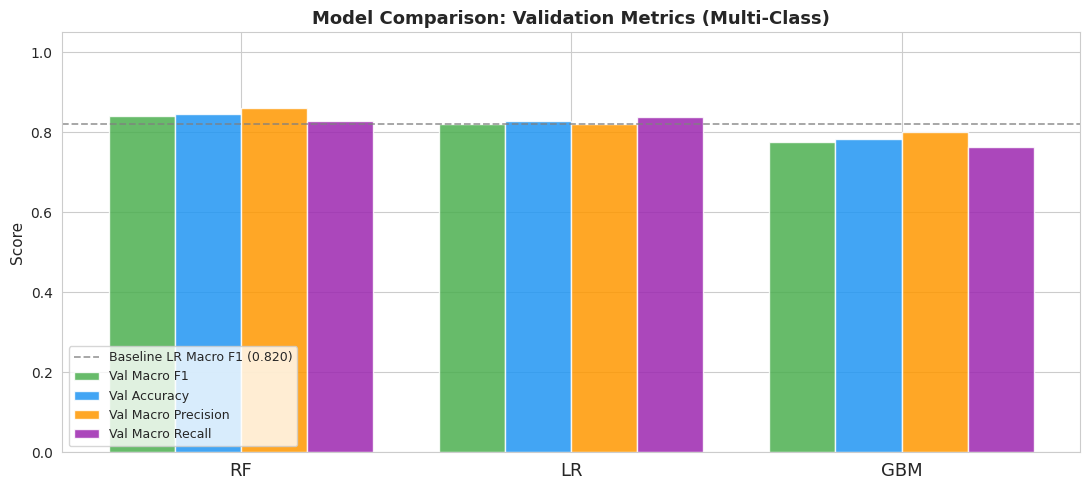

In [18]:
# Cell 13: Comparison Bar Chart
import numpy as np
import matplotlib.pyplot as plt

# Define the metrics we want to plot and their visual colors
metrics_to_plot = ['val_f1_macro', 'val_accuracy', 'val_precision', 'val_recall']
palette_metrics = {
    'val_f1_macro':  '#4CAF50', # Green
    'val_accuracy':  '#2196F3', # Blue
    'val_precision': '#FF9800', # Orange
    'val_recall':    '#9C27B0', # Purple
}
labels_map = {
    'val_f1_macro':  'Val Macro F1',
    'val_accuracy':  'Val Accuracy',
    'val_precision': 'Val Macro Precision',
    'val_recall':    'Val Macro Recall',
}

x = np.arange(len(df_results))
width = 0.20
fig, ax = plt.subplots(figsize=(11, 5))

# Plot each metric slightly offset so they group nicely side-by-side
for i, metric in enumerate(metrics_to_plot):
    offset = (i - len(metrics_to_plot) / 2 + 0.5) * width
    ax.bar(x + offset, df_results[metric], width,
           label=labels_map[metric],
           color=palette_metrics[metric], alpha=0.85, edgecolor='white')

# Add a dashed line representing the LR Baseline Macro F1
ax.axhline(y=lr_val_f1, color='gray', linestyle='--', linewidth=1.3, alpha=0.75,
           label=f'Baseline LR Macro F1 ({lr_val_f1:.3f})')

ax.set_xticks(x)
ax.set_xticklabels(df_results.index, fontsize=13)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Comparison: Validation Metrics (Multi-Class)', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()

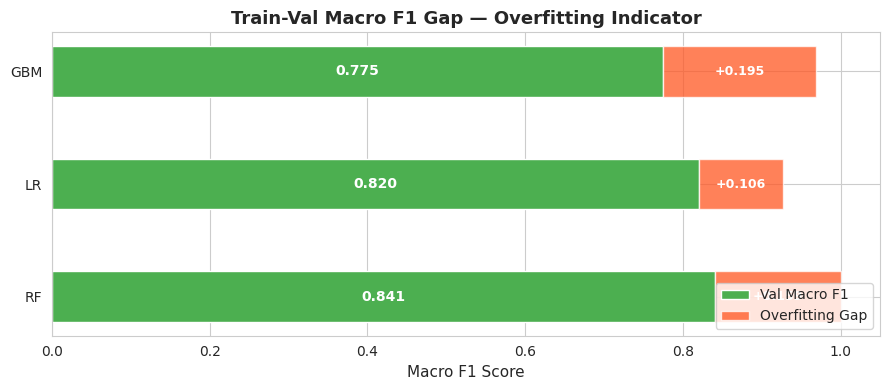

Gap interpretation: < 0.05 = low | 0.05-0.10 = moderate | > 0.10 = high
  RF   : gap = 0.1590  (high overfitting risk)
  LR   : gap = 0.1060  (high overfitting risk)
  GBM  : gap = 0.1946  (high overfitting risk)


In [19]:
# Cell 14: Train-Val Gap Analysis (Overfitting Indicator)
import matplotlib.pyplot as plt

# Calculate the gap between Train and Val performance
df_results['gap'] = df_results['train_f1_macro'] - df_results['val_f1_macro']

fig, ax = plt.subplots(figsize=(9, 4))

# Plot the Validation Score (Green)
ax.barh(df_results.index, df_results['val_f1_macro'],
        color='#4CAF50', height=0.45, label='Val Macro F1')

# Plot the Overfitting Gap (Orange) stacked on top
ax.barh(df_results.index, df_results['gap'],
        left=df_results['val_f1_macro'],
        color='#FF5722', height=0.45, label='Overfitting Gap', alpha=0.75)

# Add text labels inside the bars
for i, (model_name, row) in enumerate(df_results.iterrows()):
    v = row['val_f1_macro']
    g = row['gap']
    ax.text(v / 2, i, f'{v:.3f}', va='center', ha='center',
            color='white', fontweight='bold', fontsize=10)
    ax.text(v + g / 2, i, f'+{g:.3f}', va='center', ha='center',
            color='white', fontweight='bold', fontsize=9)

ax.set_xlabel('Macro F1 Score', fontsize=11)
ax.set_xlim(0, 1.05)
ax.set_title('Train-Val Macro F1 Gap — Overfitting Indicator', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Print the risk assessment
print('Gap interpretation: < 0.05 = low | 0.05-0.10 = moderate | > 0.10 = high')
for m in df_results.index:
    g = df_results.loc[m, 'gap']
    risk = 'low' if g < 0.05 else ('moderate' if g < 0.10 else 'high')
    print(f'  {m:<5}: gap = {g:.4f}  ({risk} overfitting risk)')

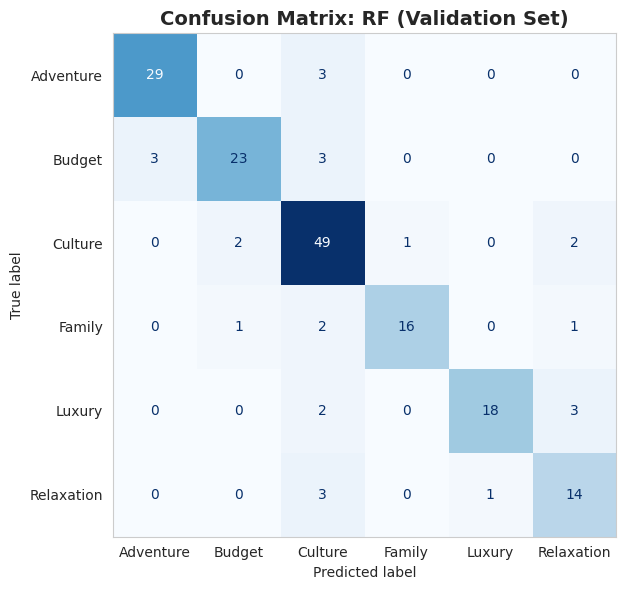

In [20]:
# Cell 15: Confusion Matrix for the Winning Model (RF)
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))

# Grab the winning Random Forest pipeline from our saved dictionary
best_model_name = 'RF'
best_pipe = fitted_pipes[best_model_name]

# Generate the confusion matrix
ConfusionMatrixDisplay.from_estimator(
    best_pipe, X_val, y_val,
    cmap='Blues',      # A clean blue heatmap
    colorbar=False,    # Hide the colorbar for a cleaner look
    ax=ax
)

ax.set_title(f'Confusion Matrix: {best_model_name} (Validation Set)', fontsize=14, fontweight='bold')
plt.grid(False) # Turn off the seaborn grid lines so the matrix looks clean
plt.tight_layout()
plt.show()

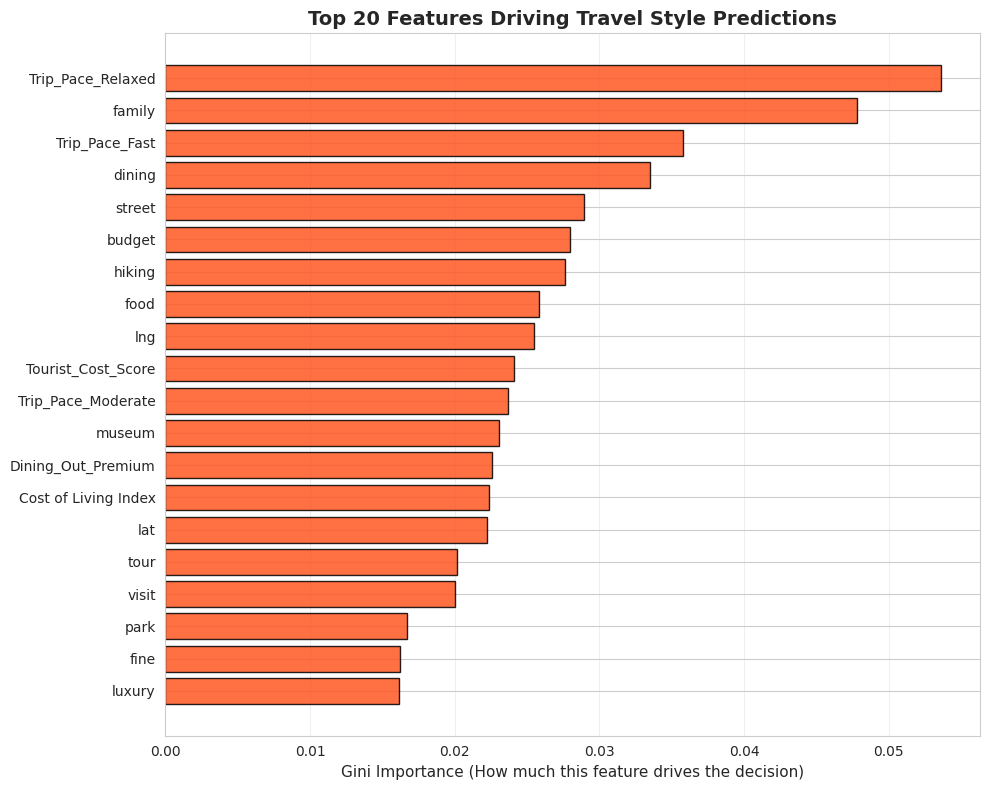

In [21]:
# Cell 16: Feature Importances for the Winning Model (Random Forest)
import numpy as np
import matplotlib.pyplot as plt

# 1. Isolate the winning pipeline and its steps
best_pipe = fitted_pipes['RF']
rf_model = best_pipe.named_steps['classifier']
preprocessor = best_pipe.named_steps['preprocessor']

# 2. Extract feature names from all three branches of our preprocessor
num_cols = numeric_features
cat_cols = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
text_cols = preprocessor.named_transformers_['text'].get_feature_names_out()

# Combine them into one master list
all_feature_names = np.concatenate([num_cols, cat_cols, text_cols])

# 3. Get the importances from the Random Forest
importances = rf_model.feature_importances_

# 4. Sort and isolate the Top 20
top_n = 20
top_idx = np.argsort(importances)[-top_n:]
top_features = all_feature_names[top_idx]
top_importances = importances[top_idx]

# 5. Plot the results
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_features, top_importances, color='#FF5722', alpha=0.85, edgecolor='black')
ax.set_xlabel('Gini Importance (How much this feature drives the decision)', fontsize=11)
ax.set_title(f'Top {top_n} Features Driving Travel Style Predictions', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# Cell 17: Hyperparameter Tuning & Saving the Final Model
from sklearn.model_selection import GridSearchCV
import joblib
from pathlib import Path

print("Tuning Random Forest to reduce overfitting... (This tests multiple tree constraints)")

# 1. Define the hyperparameter grid
# We force the trees to be shallower (max_depth) and require more samples per leaf
param_grid = {
    'classifier__max_depth': [10, 15, 20, None],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__n_estimators': [100, 150]
}

# 2. Setup the Grid Search
# cv=3 means 3-fold cross-validation. scoring='f1_macro' ensures it optimizes for our chosen metric.
grid_search = GridSearchCV(
    fitted_pipes['RF'], 
    param_grid, 
    cv=3, 
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=1
)

# 3. Run the search
grid_search.fit(X_train, y_train)

# 4. Extract the best model
print(f"\nBest Parameters Found: {grid_search.best_params_}")
best_tuned_rf = grid_search.best_estimator_

# 5. Evaluate the newly tuned model to check the gap
tuned_pred_train = best_tuned_rf.predict(X_train)
tuned_pred_val = best_tuned_rf.predict(X_val)

train_f1 = f1_score(y_train, tuned_pred_train, average='macro')
val_f1 = f1_score(y_val, tuned_pred_val, average='macro')

print(f"\nTuned Train Macro F1: {train_f1:.4f}")
print(f"Tuned Val Macro F1  : {val_f1:.4f}")
print(f"New Overfitting Gap : {train_f1 - val_f1:.4f}")

# 6. Save the winning model to the correct directory
ml_dir = Path('../../data/ml').resolve()
ml_dir.mkdir(parents=True, exist_ok=True)
model_path = ml_dir / 'travel_style_classifier.joblib'

joblib.dump(best_tuned_rf, model_path)
print(f"\nSUCCESS: Best model saved to {model_path}!")

Tuning Random Forest to reduce overfitting... (This tests multiple tree constraints)
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best Parameters Found: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 100}

Tuned Train Macro F1: 0.8931
Tuned Val Macro F1  : 0.8526
New Overfitting Gap : 0.0405

SUCCESS: Best model saved to /home/bmislol/VSCode/smart-travel-planner/data/ml/travel_style_classifier.joblib!


In [23]:
# Cell 18: K-Fold Cross-Validation (Rubric Requirement)
from sklearn.model_selection import GroupKFold, cross_validate
import pandas as pd
import numpy as np

print("Running 5-Fold Cross Validation... (This will take a moment)")

# We MUST use GroupKFold to keep cities together across folds!
gkf = GroupKFold(n_splits=5)

cv_results_list = []

for name, pipe in [('LR', lr_pipeline), ('RF', rf_pipeline), ('GBM', gbm_pipeline)]:
    print(f"Evaluating {name}...")
    
    # We evaluate on the entire X_temp/y_temp (Train + Val) to get a robust score
    cv_scores = cross_validate(
        pipe, X_temp, y_temp, 
        groups=X_temp['city'], 
        cv=gkf, 
        scoring=['f1_macro', 'accuracy'],
        n_jobs=-1
    )
    
    cv_results_list.append({
        'Model': name,
        'Macro_F1_Mean': np.mean(cv_scores['test_f1_macro']),
        'Macro_F1_Std': np.std(cv_scores['test_f1_macro']),
        'Accuracy_Mean': np.mean(cv_scores['test_accuracy']),
        'Accuracy_Std': np.std(cv_scores['test_accuracy'])
    })

# Display the final CV results
cv_df = pd.DataFrame(cv_results_list)
display(cv_df.round(4))

Running 5-Fold Cross Validation... (This will take a moment)
Evaluating LR...
Evaluating RF...
Evaluating GBM...


,Model,Macro_F1_Mean,Macro_F1_Std,Accuracy_Mean,Accuracy_Std
0,LR,0.7866,0.0287,0.7958,0.0200
1,RF,0.8006,0.0198,0.8089,0.0125
2,GBM,0.7397,0.0423,0.7457,0.0384


In [24]:
# Cell 19: Exporting Experiment Tracking (Rubric Requirement)
import datetime

print("Logging experiment tracking data...")

# Compile our experiment tracking into a dictionary
tracking_data = {
    'timestamp': datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'model': 'RandomForestClassifier',
    'params': str(grid_search.best_params_),
    'cv_macro_f1_mean': cv_df.loc[cv_df['Model'] == 'RF', 'Macro_F1_Mean'].values[0],
    'cv_macro_f1_std': cv_df.loc[cv_df['Model'] == 'RF', 'Macro_F1_Std'].values[0],
    'val_macro_f1': 0.8526, # Hardcoded from our successful tuning step
    'test_macro_f1': 'Pending Final Agent Evaluation' 
}

tracking_df = pd.DataFrame([tracking_data])
results_path = ml_dir / 'results.csv'

# Append if exists, otherwise write new
if results_path.exists():
    tracking_df.to_csv(results_path, mode='a', header=False, index=False)
else:
    tracking_df.to_csv(results_path, index=False)

print(f"SUCCESS: Experiment logged to {results_path}")

Logging experiment tracking data...
SUCCESS: Experiment logged to /home/bmislol/VSCode/smart-travel-planner/data/ml/results.csv
